In [1]:
import os
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
import numpy as np
sems = [
    [5, 5, 5, 5, 5, 3.5, 4.5, 5, 5, 5],
    [5, 5, 4.5, 5, 5, 5, 5, 5, 5, 5, 5],
    [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4.5, 4.5],
    [4, 4, 4, 5, 5, 4.5, 3.5, 4.5, 4, 4.5, 3, 5, 4.5],
    [5, 5, 4.5, 4.5, 5, 4, 4, 5, 5, 4, 5, 4.5, 5],
    [4.5, 4.5, 5, 5, 5, 4.5, 5, 4, 4, 5, 5],
    [5, 5, 5, 4.5, 5, 3.5, 5, 5, 5, 5, 5],
]

sum = np.sum(score for sem in sems for score in sem)
n = np.sum(len(sem) for sem in sems)
sum / n

C:\Users\Tim\AppData\Local\Temp\ipykernel_18048\3201811522.py:12: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  sum = np.sum(score for sem in sems for score in sem)
C:\Users\Tim\AppData\Local\Temp\ipykernel_18048\3201811522.py:13: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  n = np.sum(len(sem) for sem in sems)


4.719512195121951

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [3]:
root = Path(path)
data_root = root / "plantvillage dataset" / "color" # or "grayscale"

In [4]:
def select_device():
    return 'cuda' if torch.cuda.is_available() else ('mps' if torch.mps.is_available() else 'cpu')

device = select_device()
device

'cuda'

In [5]:
IMG_SIZE = 128

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

In [6]:
full_ds = datasets.ImageFolder(data_root, transform=train_tfms)
all_classes = full_ds.classes
print("Total classes:", len(all_classes))
print("Example classes:", all_classes[:10])

N_CLASSES = 5
selected_classes = all_classes[:N_CLASSES]
selected_class_to_idx = {c: full_ds.class_to_idx[c] for c in selected_classes}
print("Selected:", selected_classes)

# wybieramy indeksy próbek należących do wybranych klas
sel_indices = [i for i, (_, y) in enumerate(full_ds.samples) if y in selected_class_to_idx.values()]
ds_sel = Subset(full_ds, sel_indices)

# split
n = len(ds_sel)
n_train = int(0.8 * n)
n_val = int(0.1 * n)
n_test = n - n_train - n_val

g = torch.Generator().manual_seed(42)
ds_train, ds_val, ds_test = random_split(ds_sel, [n_train, n_val, n_test], generator=g)

# val/test powinny mieć eval_tfms, więc podmieniamy transform w "bazowym" dataset
full_ds_eval = datasets.ImageFolder(data_root, transform=eval_tfms)
ds_sel_eval = Subset(full_ds_eval, sel_indices)
ds_train = Subset(ds_sel, ds_train.indices)     # train z augmentacją
ds_val = Subset(ds_sel_eval, ds_val.indices)    # val bez augmentacji
ds_test = Subset(ds_sel_eval, ds_test.indices)  # test bez augmentacji

len(ds_train), len(ds_val), len(ds_test)

Total classes: 38
Example classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']
Selected: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


(3738, 467, 468)

In [7]:
BATCH_SIZE = 128
num_dl_workers = 0

train_dl = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_dl_workers, pin_memory=True)
val_dl   = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_dl_workers, pin_memory=True)
test_dl  = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_dl_workers, pin_memory=True)

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 128 -> 64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64 -> 32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 -> 16
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

num_classes = N_CLASSES
model = SimpleCNN(num_classes).to(device)
model = torch.compile(model)
model

OptimizedModule(
  (_orig_mod): SimpleCNN(
    (features): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (classifier): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=32768, out_features=256, bias=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=256, out_features=5, bias=True)
    )
  )
)

In [9]:
def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

In [10]:
from torch.amp import autocast, GradScaler

def run_epoch(model, dl, optimizer=None, loss_fn=None, scaler=None):
    train = optimizer is not None
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total = 0

    for x, y in tqdm(dl, desc="train" if train else "eval", leave=False):
        x, y = x.to(device), y.to(device)

        with torch.set_grad_enabled(train), autocast(device_type=device):
            logits = model(x)
            loss = loss_fn(logits, y)

        if train:
            optimizer.zero_grad(set_to_none=True)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        total_loss += loss.item() * y.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, total_correct / total

In [11]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.7 MB/s eta 0:00:00


In [12]:
EPOCHS = 10

In [13]:
import optuna

def objective(trial):
    # Suggest hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-2)
    wd = trial.suggest_float("wd", 1e-5, 1e-2)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    train_dl = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=num_dl_workers, pin_memory=True)
    val_dl   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=num_dl_workers, pin_memory=True)

    # Create a fresh model
    model = SimpleCNN(num_classes).to(device)
    model = torch.compile(model)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()
    scaler = GradScaler(device=device)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(EPOCHS):
        train_loss, train_acc = run_epoch(model, train_dl, optimizer, loss_fn, scaler)
        val_loss, val_acc = run_epoch(model, val_dl, optimizer=None, loss_fn=loss_fn, scaler=scaler)

        # optional: report intermediate results for pruning
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

    # Save current model
    torch.save(model.state_dict(), f"trial_{trial.number}_model.pth")

    trial.set_user_attr("val_loss", val_loss)
    trial.set_user_attr("val_acc", val_acc)
    trial.set_user_attr("train_loss", train_loss)
    trial.set_user_attr("train_acc", train_acc)
    trial.set_user_attr("history", history)

    return val_acc  # what Optuna tries to maximize

In [14]:
study = optuna.create_study(direction="maximize", study_name="cnn_image_sweep")
study.optimize(objective, n_trials=9, n_jobs=3) # Colab will fail for n_jobs > 3

[I 2026-03-18 00:09:21,457] A new study created in memory with name: cnn_image_sweep


train:   0%|          | 0/117 [00:00<?, ?it/s]

train:   0%|          | 0/59 [00:00<?, ?it/s]

train:   0%|          | 0/59 [00:00<?, ?it/s]

W0318 00:09:26.803000 1640 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


...

eval:   0%|          | 0/4 [00:00<?, ?it/s]

eval:   0%|          | 0/4 [00:00<?, ?it/s]

[I 2026-03-18 00:21:45,481] Trial 6 pruned. 
[I 2026-03-18 00:21:46,805] Trial 7 pruned. 


eval:   0%|          | 0/8 [00:00<?, ?it/s]

[I 2026-03-18 00:21:52,078] Trial 8 pruned. 


In [15]:
best_trial = study.best_trial
print("Best validation accuracy:", best_trial.value)
print("Best hyperparameters:", best_trial.params)

# see all metrics
for t in study.trials:
    print(t.params, t.user_attrs)

Best validation accuracy: 0.9014989293361885
Best hyperparameters: {'lr': 0.0026213385844431115, 'wd': 0.004097301307702665, 'batch_size': 64}
{'lr': 0.0026213385844431115, 'wd': 0.004097301307702665, 'batch_size': 64} {'val_loss': 0.24442628715227196, 'val_acc': 0.9014989293361885, 'train_loss': 0.3313363158348858, 'train_acc': 0.8830925628678438, 'history': {'train_loss': [1.3088792130996862, 0.7292041897199701, 0.5977609447772136, 0.5527849754526885, 0.5309275774760576, 0.4764622397094949, 0.42217281099594234, 0.38523315152361665, 0.39780172885835585, 0.3313363158348858], 'train_acc': [0.5358480470840021, 0.7268592830390583, 0.7803638309256287, 0.8033707865168539, 0.812199036918138, 0.8330658105939005, 0.8480470840021401, 0.8630283574103799, 0.8649010165864098, 0.8830925628678438], 'val_loss': [0.8737878513540395, 0.577021215789068, 0.4565050996345422, 0.4305848504159384, 0.31609580769528667, 0.35349354384032255, 0.22568276735138332, 0.30590145407958513, 0.2739181360927843, 0.244426

In [18]:
state_dict = torch.load(f"trial_{best_trial.number}_model.pth")
new_state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}

model = SimpleCNN(num_classes).to(device)
model.load_state_dict(new_state_dict)
model.eval()

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=5, bias=True)
  )
)

# Wizualizacje

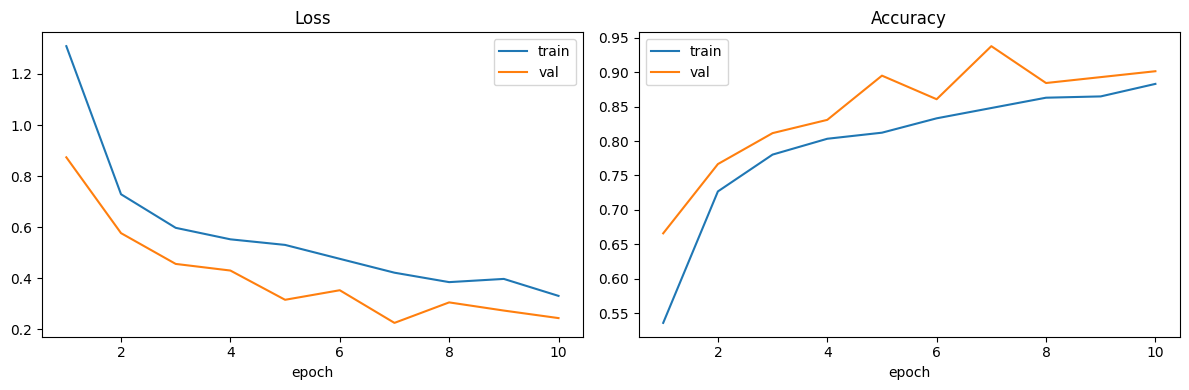

In [19]:
history = best_trial.user_attrs["history"]

ep = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(ep, history["train_loss"], label="train")
plt.plot(ep, history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ep, history["train_acc"], label="train")
plt.plot(ep, history["val_acc"], label="val")
plt.title("Accuracy")
plt.xlabel("epoch")
plt.legend()
plt.tight_layout()
plt.show()

# Test accuracy:

In [20]:
te_loss, te_acc = run_epoch(model, test_dl, optimizer=None, loss_fn=nn.CrossEntropyLoss())
print(f"TEST: loss = {te_loss}, accuracy = {te_acc}")

eval:   0%|          | 0/4 [00:00<?, ?it/s]

TEST: loss = 0.29653712801444226, accuracy = 0.8931623931623932


# Wizualizacja augmentacji

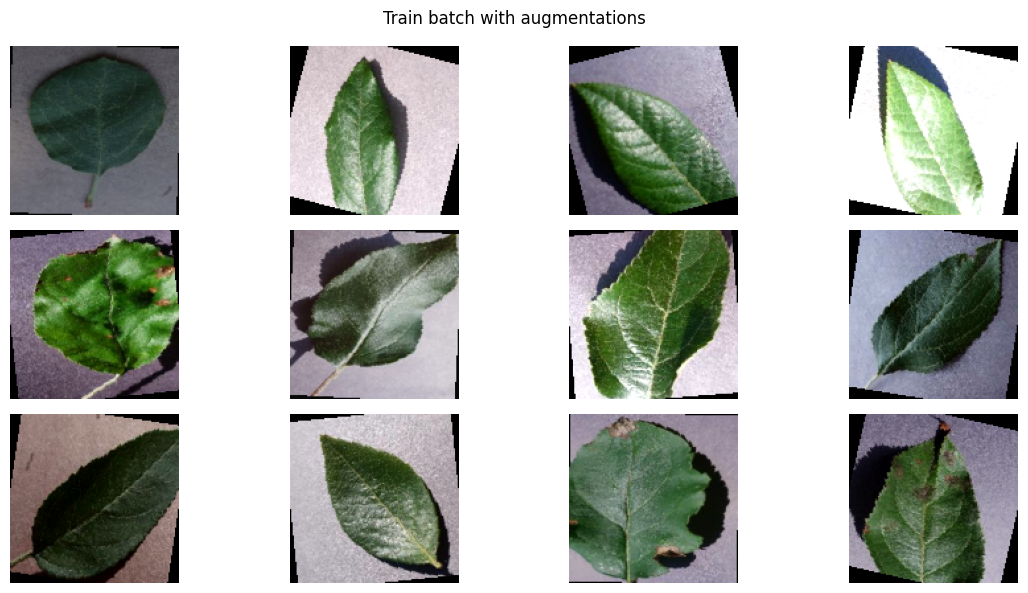

In [21]:
# kilka przykładów z train
x, y = next(iter(train_dl))

# odnormalizujemy z powrotem
mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)
x_vis = (x.cpu() * std + mean).clamp(0,1)

plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(np.transpose(x_vis[i].numpy(), (1,2,0)))
    plt.axis("off")
plt.suptitle("Train batch with augmentations")
plt.tight_layout()
plt.show()

# Wizualizacja filtrów splotowych (Conv1)

In [22]:
from torchvision import utils

def visTensor(tensor, ch=0, allkernels=False, nrow=8, padding=1):
    n,c,w,h = tensor.shape

    if allkernels: tensor = tensor.view(n*c, -1, w, h)
    elif c != 3: tensor = tensor[:,ch,:,:].unsqueeze(dim=1)

    rows = np.min((tensor.shape[0] // nrow + 1, 64))
    grid = utils.make_grid(tensor, nrow=nrow, normalize=True, padding=padding)
    plt.figure( figsize=(nrow * 2,rows * 2) )
    # change ordering since matplotlib requires images to numpy image: (H x W x C) and torch image: (C X H X W)
    plt.imshow(grid.numpy().transpose((1, 2, 0)))

In [23]:
def get_first_conv2d(m):
    for layer in m.modules():
        if isinstance(layer, torch.nn.Conv2d):
            return layer
    raise ValueError("No Conv2d layer found in model")

conv1 = get_first_conv2d(model) # model.features[0]
print("Conv1:", conv1)

Conv1: Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [24]:
kernels = conv1.weight.detach().cpu().clone()
kernels.shape

torch.Size([32, 3, 3, 3])

### wizualizacja kerneli pierwszej warstwy konwolucyjnej

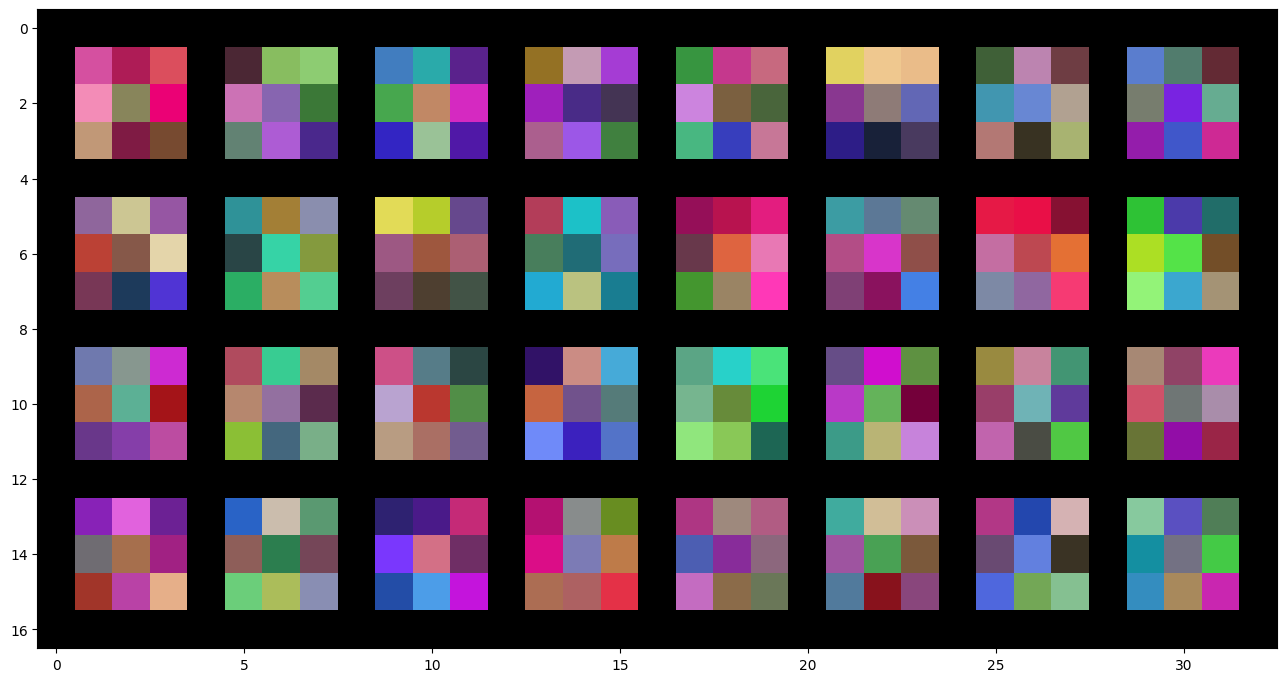

In [25]:
visTensor(kernels, ch=0, allkernels=False)

In [26]:
# hook żeby przechwycić wyjście conv1
activ = {}

def hook_fn(module, inp, out):
    activ["conv1_out"] = out.detach()

handle = conv1.register_forward_hook(hook_fn)

# kilka obrazów z train_dl
x, y = next(iter(train_dl))
x = x.to(device)

# forward (hook zapisze conv1 output)
model.eval()
with torch.no_grad():
    _ = model(x)

handle.remove()

In [29]:
feat = activ["conv1_out"].cpu()  # shape: [B, C, H, W]
print("conv1_out shape:", feat.shape)

# odnormalizujmy wejścia do wizualizacji
mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)
x_vis = (x.cpu() * std + mean).clamp(0, 1)

conv1_out shape: torch.Size([128, 32, 128, 128])


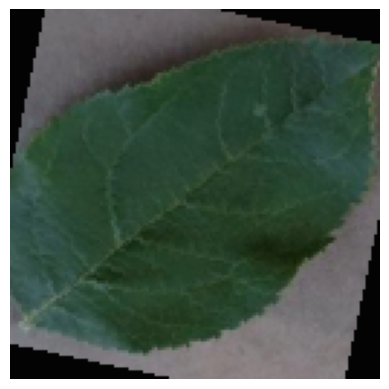

In [30]:
img = np.transpose(x_vis[0].numpy(), (1,2,0))
plt.imshow(img)
plt.axis("off")
plt.show()

### wizualizacja wyników działania 1 warstwy konwolucyjnej dla powyższego obrazu

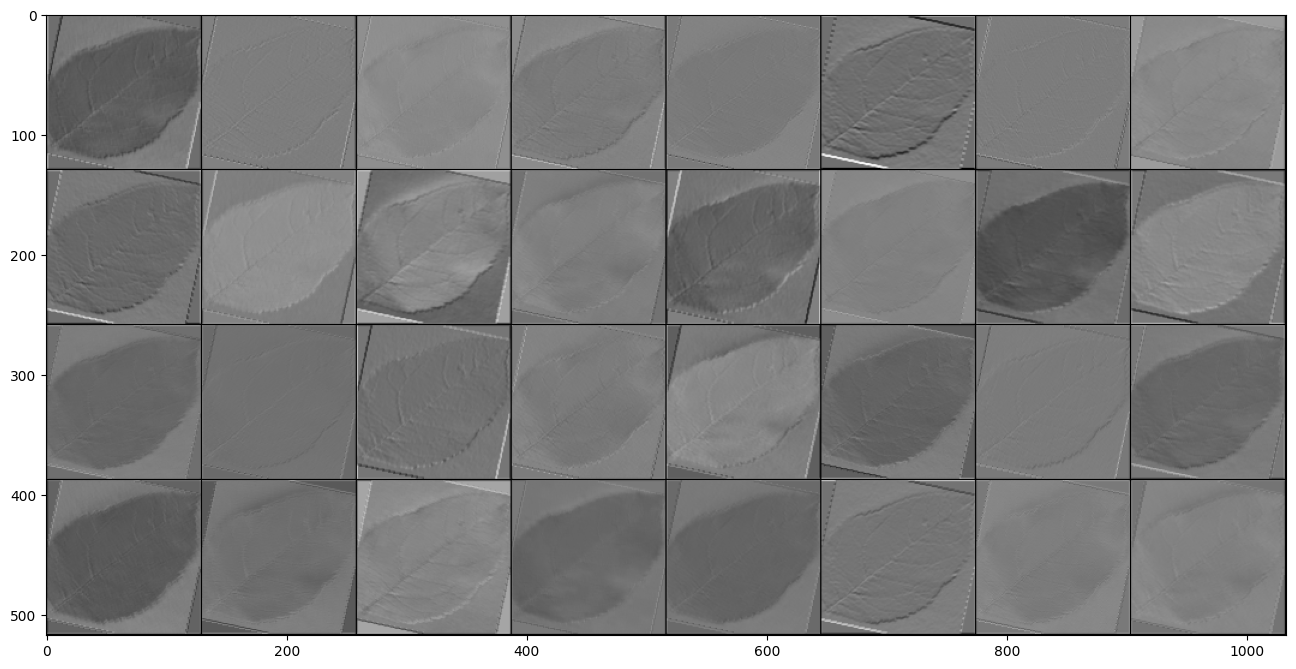

In [31]:
visTensor(feat[0].unsqueeze(1), allkernels=False)

### Heat-mapa działań kilku przykładowych filtrów

In [32]:
def overlay_heatmap_on_image(img_rgb, heatmap, alpha=0.45, cmap="magma"):
    """
    img_rgb: [H,W,3] in [0,1]
    heatmap: [H,W] arbitrary, will be normalized to [0,1]
    """
    h = heatmap.numpy()
    h = (h - h.min()) / (h.max() - h.min() + 1e-8)

    colored = plt.get_cmap(cmap)(h)[..., :3]  # [H,W,3]
    out = (1 - alpha) * img_rgb + alpha * colored
    return np.clip(out, 0, 1)

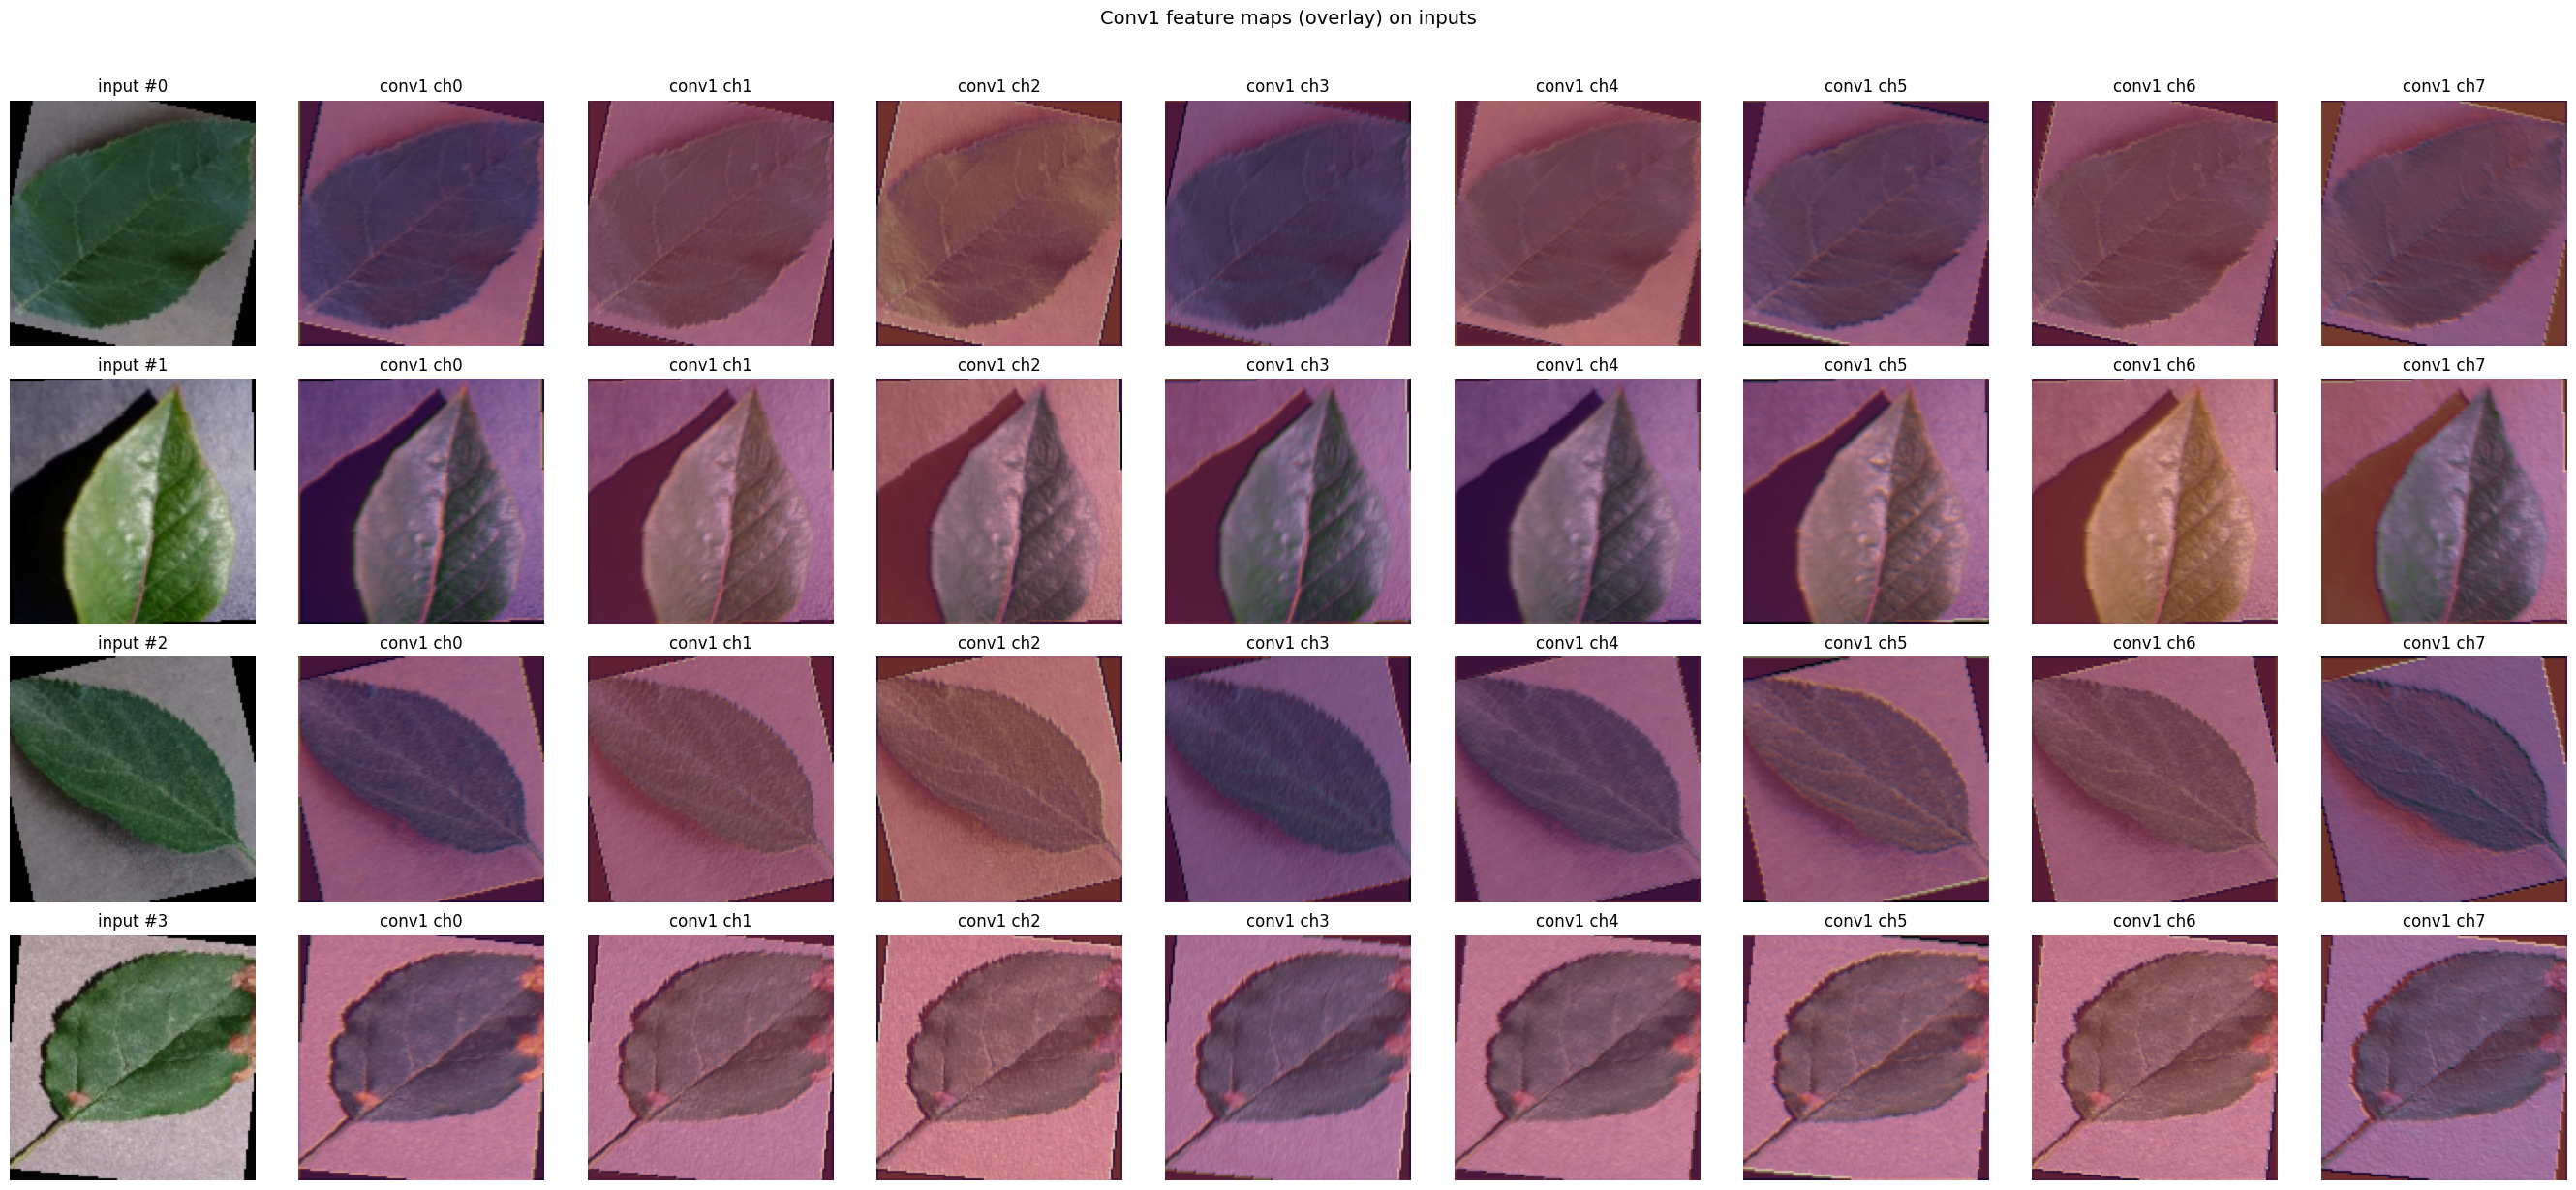

In [33]:
B = min(4, x_vis.shape[0])         # ile obrazów
K = min(8, feat.shape[1])          # ile filtrów/kanalów z conv1 pokazać

plt.figure(figsize=(3*(K+1), 3*B))

for i in range(B):
    # input
    img = np.transpose(x_vis[i].numpy(), (1,2,0))  # [H,W,3]
    ax = plt.subplot(B, K+1, i*(K+1) + 1)
    ax.imshow(img)
    ax.set_title(f"input #{i}")
    ax.axis("off")

    # overlay dla K kanałów conv1
    for k in range(K):
        hm = feat[i, k]  # [H',W']

        overlay = overlay_heatmap_on_image(img, hm, alpha=0.45, cmap="magma")

        ax = plt.subplot(B, K+1, i*(K+1) + 2 + k)
        ax.imshow(overlay)
        ax.set_title(f"conv1 ch{k}")
        ax.axis("off")

plt.suptitle("Conv1 feature maps (overlay) on inputs", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()